
## (29, 'o_hmt') model for PDF shaping (n samples)

This uses the new object oriented class for PDF shaping.

* (29, 'o_hmt')...... i_h2i_rate, i_h2_temp, i_ng_rate, i_ng_temp, i_pci_rate, i_wpi_rate, i_sgi_rate, i_sgi_COH2ratio, i_sgi_ReProRatio, i_o2_volfract, i_hbtemp, i_wind_rt, i_blast_H2O, i_bdn_H2O

## Web applicationi inputs and 1 outputs

Run interactively on the web at: https://rcalix1.github.io/ProbabilityDensityFunctionsFromNeuralNets/experiments/2023/july2023/XGBoost/deployment/tuyere/




## Inputs


(2, 'i_h2i_rate').........i_h2i_rate

(3, 'i_pci_rate').........i_pci_rate

(4, 'i_wpi_rate').........i_wpi_rate

(5, 'i_ngi_rate').........i_ng_rate

(6, 'i_o2_volfract').......i_o2_volfract

(7, 'i_ng_temp')...........i_ng_temp

(8, 'i_h2_temp')...........i_h2_temp

(9, 'i_hbtemp')............i_hbtemp

(10, 'i_wind_rt')..........i_wind_rt

(11, 'i_blastH2O').........i_blast_H2O

(12, 'i_BdnH2O')............i_bdn_H2O

(13, 'i_sgi_rate').........i_sgi_rate

(15, 'i_sgi_COH2ratio').....i_sgi_COH2ratio

(16, 'i_sgi_ReProRatio')....i_sgi_ReProRatio


  

## Outputs


(29, 'o_hmt')





## Installs


In [1]:

## !pip install xgboost
## !pip install onnxmltools
## !pip install onnxruntime



## Imports


In [2]:

import torch
import numpy as np
import pandas as pd
import sklearn
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import math
import seaborn as sns
import random
import functorch


import torch.optim as optim


from numpy.random import normal
from scipy.stats import norm
import scipy.stats as stats
from numpy import hstack
from numpy import vstack
from numpy import exp
from sklearn.neighbors import KernelDensity

##from typing import Optional

from torch import Tensor


from torch.utils.data import TensorDataset, DataLoader

from mlxtend.plotting import heatmap

## coefficient of determination (R**2)
from sklearn.metrics import r2_score

np.set_printoptions(suppress=True)
torch.set_printoptions(sci_mode=False)




In [5]:

import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor, DMatrix, train as train_xgb
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import onnxmltools
from onnxmltools.convert.xgboost.operator_converters.XGBoost import (
    convert_xgboost)
from onnxmltools.convert import convert_xgboost as convert_xgboost_booster


from zipfile import ZipFile
from skl2onnx.common.data_types import FloatTensorType
from skl2onnx import convert_sklearn, to_onnx, update_registered_converter
from skl2onnx.common.shape_calculator import (
    calculate_linear_classifier_output_shapes,
    calculate_linear_regressor_output_shapes)


# Import the ONNX runtime environment
import onnxruntime as rt



In [6]:

import PDFshapingUtils as PDF_tk



## Instantiate PDF shaping and regression class


In [7]:

PDFshapingOBJ = PDF_tk.PDFshapingUtils()



## Initialize parameters


In [8]:

PDFshapingOBJ.N_error_range = 5         ## 20
PDFshapingOBJ.mean_impulse  = 0.0       ## -7.0      ## 0.0
PDFshapingOBJ.std_impulse   = 0.001     ## 1.0
PDFshapingOBJ.kde_std       = 0.5       ## 0.1       ## 0.5      ## 3.0  ## smaller is better approximation?
PDFshapingOBJ.bandwidth     = 0.2       ## 0.2->more jagged, 2.0->more smooth


In [9]:

PDFshapingOBJ.initializeImpulseGaussian()



## Run checks


In [10]:

## print(PDFshapingOBJ.x_range_impulse_func )
## print(PDFshapingOBJ.impulse_func_vector_vals )
## print(PDFshapingOBJ.quadratic_weights)
print(PDFshapingOBJ.x_range_impulse_func.shape )
print(PDFshapingOBJ.impulse_func_vector_vals.shape )
print(PDFshapingOBJ.quadratic_weights.shape)
 
print( sum(PDFshapingOBJ.impulse_func_vector_vals) )      ## should add up to 100 (i.e. 1.0 prob density)


torch.Size([1000])
torch.Size([1000])
torch.Size([1000])
tensor(100.0000)


In [11]:

## plt.plot(PDFshapingOBJ.x_range_impulse_func, PDFshapingOBJ.impulse_func_vector_vals)
## plt.show()



## RUN KDE test


In [12]:

## PDFshapingOBJ.test_torchKDE_with_fake_data()



## Load Data


In [13]:

PDFshapingOBJ.read_csv_file_with_pandas('CFD.16.2025.csv')


In [14]:

PDFshapingOBJ.CFD_raw_data


,index,case name,i_h2i_rate,i_pci_rate,i_wpi_rate,i_ngi_rate,i_o2_volfract,i_ng_temp,i_h2_temp,i_hbtemp,...,o_h2o_sollos,o_feo_sollos,o_hm_rt,o_mw_rt,o_wf_rt,o_hm_h2share,o_mw_h2share,o_wf_h2share,o_prod_rt,o_fta
0,1,H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HB...,0,0,0,120,21,300,0,1200,...,20.0,44.9,122.0,264.0,687.0,31.6,26.7,63.5,4050.0,1800.0
1,2,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,0,1200,...,18.5,52.6,122.0,265.0,684.0,27.9,23.4,60.6,4060.0,1850.0
2,3,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,0,1200,...,19.6,50.9,123.0,266.0,690.0,27.7,23.5,60.8,4080.0,1850.0
3,4,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,0,1200,...,19.2,52.2,124.0,268.0,690.0,27.7,23.2,60.6,4090.0,1850.0
4,5,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,0,1200,...,19.2,52.4,124.0,268.0,695.0,27.7,23.2,60.7,4110.0,1850.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,4995,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,18.7,40.3,353.0,763.0,2190.0,34.0,20.5,56.7,11700.0,2380.0
4995,4996,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,18.7,40.7,353.0,763.0,2190.0,33.8,20.4,56.8,11700.0,2310.0
4996,4997,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,19.2,37.5,353.0,763.0,2230.0,33.6,20.4,57.1,11700.0,2380.0
4997,4998,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,17.6,39.8,355.0,768.0,2220.0,34.0,20.0,55.7,11800.0,2310.0


In [15]:

PDFshapingOBJ.print_headers_list()


['index', 'case name', 'i_h2i_rate', 'i_pci_rate', 'i_wpi_rate', 'i_ngi_rate', 'i_o2_volfract', 'i_ng_temp', 'i_h2_temp', 'i_hbtemp', 'i_wind_rt', 'i_blastH2O', 'i_BdnH2O', 'i_sgi_rate', 'i_sgtemp', 'i_sgi_H2COratio', 'i_sgi_ReProRatio', 'o_tuy_velo', 'o_tuy_temp', 'o_burn', 'o_delp', 'o_co_vf', 'o_co2_vf', 'o_h2_vf', 'o_n2_vf', 'o_co_util', 'o_h2_util', 'o_tgt', 'o_coke_rt', 'o_hmt', 'o_co2_sollos', 'o_h2o_sollos', 'o_feo_sollos', 'o_hm_rt', 'o_mw_rt', 'o_wf_rt', 'o_hm_h2share', 'o_mw_h2share', 'o_wf_h2share', 'o_prod_rt', 'o_fta']
41
(0, 'index')
(1, 'case name')
(2, 'i_h2i_rate')
(3, 'i_pci_rate')
(4, 'i_wpi_rate')
(5, 'i_ngi_rate')
(6, 'i_o2_volfract')
(7, 'i_ng_temp')
(8, 'i_h2_temp')
(9, 'i_hbtemp')
(10, 'i_wind_rt')
(11, 'i_blastH2O')
(12, 'i_BdnH2O')
(13, 'i_sgi_rate')
(14, 'i_sgtemp')
(15, 'i_sgi_H2COratio')
(16, 'i_sgi_ReProRatio')
(17, 'o_tuy_velo')
(18, 'o_tuy_temp')
(19, 'o_burn')
(20, 'o_delp')
(21, 'o_co_vf')
(22, 'o_co2_vf')
(23, 'o_h2_vf')
(24, 'o_n2_vf')
(25, 'o_co_ut

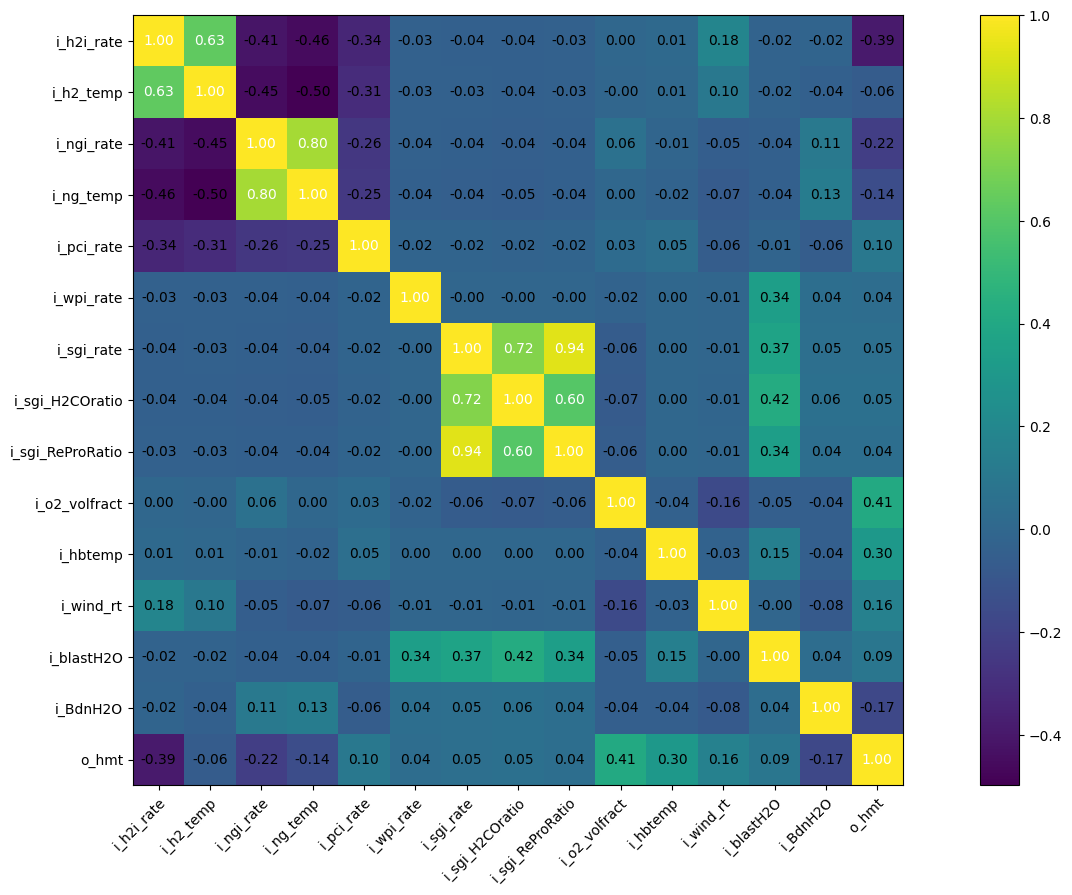

In [16]:




PDFshapingOBJ.list_of_selected_column_names = ['i_h2i_rate','i_h2_temp','i_ngi_rate','i_ng_temp','i_pci_rate',
                    'i_wpi_rate','i_sgi_rate','i_sgi_H2COratio','i_sgi_ReProRatio','i_o2_volfract',
                    'i_hbtemp','i_wind_rt','i_blastH2O','i_BdnH2O', 'o_hmt' ]

ONNX_name = 'o_hmt'


PDFshapingOBJ.print_correlation_coefficients()


In [17]:

PDFshapingOBJ.convert_pd_data_to_numpy()


[[1
  'H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-7_SGI-0_SGT-0_SGC_0 '
  0 ... 63.5 4050.0 1800.0]
 [2
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-1_SGI-0_SGT-0_SGC_0 '
  0 ... 60.6 4060.0 1850.0]
 [3
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  0 ... 60.8 4080.0 1850.0]
 ...
 [4997
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1600_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 57.1 11700.0 2380.0]
 [4998
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-3_SGI-0_SGT-0_SGC_0 '
  30 ... 55.7 11800.0 2310.0]
 [4999
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 56.2 11800.0 2310.0]]
(4999, 41)



## Select inputs and outputs


In [19]:

PDFshapingOBJ.gen_X_y_for_selected_indeces(  
                   inputs = [ 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16 ] , 
                   outputs= [ 29 ]   
)






14
1


In [20]:

print(PDFshapingOBJ.X.shape)
print(PDFshapingOBJ.y.shape)


(4999, 14)
(4999, 1)


In [21]:

PDFshapingOBJ.random_seed = int( random.random() * 100  )         ## defautl is 42


In [22]:

PDFshapingOBJ.split_np_data_train_test(selected_test_size=0.2)


(3999, 14)
(1000, 14)
(3999, 1)
(1000, 1)


In [23]:

PDFshapingOBJ.convert_dataset_from_np_to_torch()


In [24]:

PDFshapingOBJ.standardize_X_scales()
PDFshapingOBJ.standardize_y_scales()


In [25]:

PDFshapingOBJ.gen_Dataloader_train()

PDFshapingOBJ.train_dl



## NN architectures


In [26]:

#######################################################
## Linear Regression

class LinRegNet_SIO(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations):
        super().__init__()
        
        self.x_means      = x_means
        self.x_deviations = x_deviations
        self.y_means      = y_means
        self.y_deviations = y_deviations
        
        self.linear1 = nn.Linear(14, 1) 
        
        ## nn.init.xavier_uniform_(self.linear1.weight)
        ## nn.init.zeros_(self.linear1.bias)

    ## perform inference
    def forward(self, x):
        x = (x - self.x_means) / self.x_deviations
        
        y_scaled = self.linear1(x)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled

    
#############################################################
## Multi-Layer Perceptron

class MLP_Net_SIO(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations):
        super().__init__()
        
        self.x_means      = x_means
        self.x_deviations = x_deviations
        self.y_means      = y_means
        self.y_deviations = y_deviations
        
        self.linear1 = nn.Linear(14, 10)
        self.act1    = nn.Sigmoid()                       ## Tanh() 
        self.linear2 = nn.Linear(10, 1)
        self.dropout = nn.Dropout(0.25)
        
        ## nn.init.xavier_uniform_(self.linear1.weight)
        ## nn.init.zeros_(self.linear1.bias)
        
        ## nn.init.xavier_uniform_(self.linear2.weight)
        ## nn.init.zeros_(self.linear2.bias)
    
    ## perform inference
    def forward(self, x):
        x = (x - self.x_means) / self.x_deviations
        x = self.linear1(x)
        x = self.act1(x)
        x = self.dropout(x)
        
        y_scaled = self.linear2(x)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled
    

#############################################################
## Deep Learning model with 2 hidden layers


class DL_Net_SIO(nn.Module):
    
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations):
        super().__init__()
        
        self.x_means      = x_means
        self.x_deviations = x_deviations
        self.y_means      = y_means
        self.y_deviations = y_deviations
        
        self.linear1 = nn.Linear(14, 10)
        self.act1    = nn.Sigmoid()                       ## Tanh() 
        self.linear2 = nn.Linear(10, 6)
        self.act2    = nn.Sigmoid() 
        self.linear3 = nn.Linear(6, 1)
        self.dropout = nn.Dropout(0.25)
        
        ## nn.init.xavier_uniform_(self.linear1.weight)
        ## nn.init.zeros_(self.linear1.bias)
        
        ## nn.init.xavier_uniform_(self.linear2.weight)
        ## nn.init.zeros_(self.linear2.bias)
        
        ## nn.init.xavier_uniform_(self.linear3.weight)
        ## nn.init.zeros_(self.linear3.bias)
    
    ## perform inference
    def forward(self, x):
        
        x = (x - self.x_means) / self.x_deviations
        x = self.linear1(x)
        x = self.act1(x)
        x = self.dropout(x)
        x = self.linear2(x)
        x = self.act2(x)
        x = self.dropout(x)
        
        y_scaled = self.linear3(x)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled


In [27]:

#############################################################
##   F1      plus       F2
## Linear     +      Nonlinear

class F1plusF2_SIO(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations):
        super().__init__()
        
        self.x_means      = x_means
        self.x_deviations = x_deviations
        self.y_means      = y_means
        self.y_deviations = y_deviations
        
        ## F1
        self.f1_linear1 = nn.Linear(14, 1)       
        
        ## F2
        self.f2_linear1 = nn.Linear(14, 10)
        self.f2_act1    = nn.Sigmoid()                    ## Tanh()                       
        self.f2_linear2 = nn.Linear(10, 1)       
        self.f2_dropout = nn.Dropout(0.25)
        
        
    ## perform inference
    def forward(self, x):
        x = (x - self.x_means) / self.x_deviations
        
        ## F1
        f1 = self.f1_linear1(x)
        
        ## F2
        f2 = self.f2_linear1(x)
        f2 = self.f2_act1(f2)
        f2 = self.f2_dropout(f2)
        f2 = self.f2_linear2(f2)
        
        
        y_scaled   = f1 + f2
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled
    



## Results for g(x) = F1(x) + F2(x) with No PDF shaping

F1 = Linear

F2 = Nonlinear


In [28]:

def fit_y_scaled(num_epochs, model, loss_fn, opt):
    
    PDFshapingOBJ.list_metric = []
    for epoch in range(num_epochs):
        for xb, yb in PDFshapingOBJ.train_dl:
            pred_descaled, pred_scaled = model(xb)
            loss = loss_fn(pred_scaled, yb)
            loss.backward()
            opt.step()
            opt.zero_grad()
        
        if epoch % 200 == 0:
            print(epoch, " loss= ", loss)
            
            
        pred_descaled, pred_scaled = model(PDFshapingOBJ.X_train_tr)
        r2_avg = torch.mean(
            torch.tensor(
                r2_score( pred_scaled.detach().numpy(),  PDFshapingOBJ.y_train_tr_scaled.numpy()   )
            )
        )
        PDFshapingOBJ.list_metric.append(  r2_avg.detach().numpy()  )
            
    PDFshapingOBJ.func_plot_performance()
            
    pred_descaled, pred_scaled = model(PDFshapingOBJ.X_train_tr)
    print('Training loss:', loss_fn(  pred_scaled,           PDFshapingOBJ.y_train_tr_scaled          ))
    print('Training R**2:', r2_score( pred_scaled.detach().numpy(), PDFshapingOBJ.y_train_tr_scaled.numpy()  ))
    


In [29]:

PDFshapingOBJ.the_string           = "No_PDF_shaping"
PDFshapingOBJ.furnace_model_name   = ONNX_name


0  loss=  tensor(0.3825, grad_fn=<MseLossBackward0>)
200  loss=  tensor(0.0118, grad_fn=<MseLossBackward0>)
400  loss=  tensor(0.0765, grad_fn=<MseLossBackward0>)
600  loss=  tensor(0.0369, grad_fn=<MseLossBackward0>)
800  loss=  tensor(0.0794, grad_fn=<MseLossBackward0>)
1000  loss=  tensor(0.0208, grad_fn=<MseLossBackward0>)
1200  loss=  tensor(0.0627, grad_fn=<MseLossBackward0>)
1400  loss=  tensor(0.0730, grad_fn=<MseLossBackward0>)
1600  loss=  tensor(0.0753, grad_fn=<MseLossBackward0>)
1800  loss=  tensor(0.0227, grad_fn=<MseLossBackward0>)


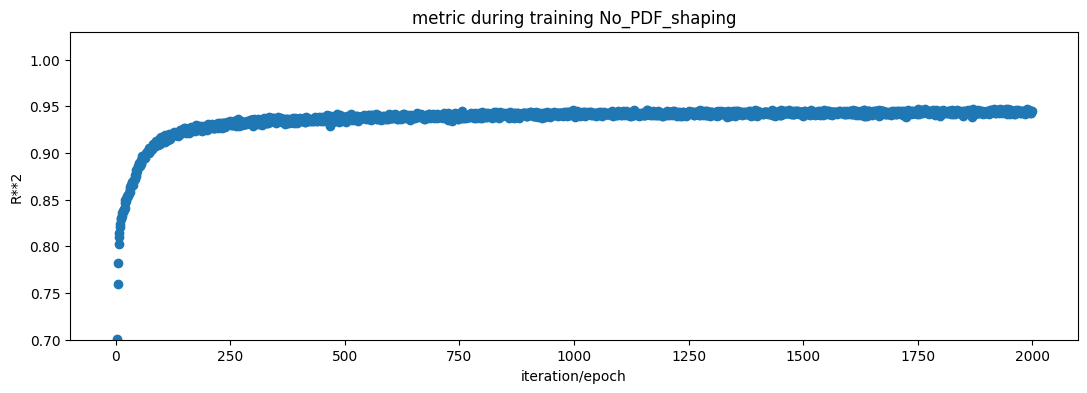

Training loss: tensor(0.0538, grad_fn=<MseLossBackward0>)
Training R**2: 0.9437019532880526
Test loss - scaled: tensor(0.0572, grad_fn=<MseLossBackward0>)
Test loss - descaled: tensor(15840.5078, grad_fn=<MseLossBackward0>)
Testing R**2 - scaled: 0.9367882293757583
Testing R**2 - descaled: 0.9367882293973804
*****
*****
Testing R**2 - Output: 0 o_hmt 0.9367882293973804


In [30]:

model = F1plusF2_SIO(
             PDFshapingOBJ.x_means, 
             PDFshapingOBJ.x_deviations, 
             PDFshapingOBJ.y_means, 
             PDFshapingOBJ.y_deviations
)

opt = torch.optim.Adam(   model.parameters(), lr=PDFshapingOBJ.learning_rate   )
loss_fn = F.mse_loss


fit_y_scaled(PDFshapingOBJ.N_EPOCHS, model, loss_fn, opt)


pred_descaled, pred_scaled = model(PDFshapingOBJ.X_test_tr)
print('Test loss - scaled:',   loss_fn(     pred_scaled,         PDFshapingOBJ.y_test_tr_scaled          ))
print('Test loss - descaled:', loss_fn(     pred_descaled,       PDFshapingOBJ.y_test_tr                 ))
print('Testing R**2 - scaled:', r2_score( pred_scaled.detach().numpy(), PDFshapingOBJ.y_test_tr_scaled.numpy() ))
print('Testing R**2 - descaled:', r2_score( pred_descaled.detach().numpy(), PDFshapingOBJ.y_test_tr.numpy()    ))

PDFshapingOBJ.print_individual_Rsquare(pred_descaled, PDFshapingOBJ.y_test_tr)


In [31]:

list_preds = []
list_reals = []

for i in range(len(PDFshapingOBJ.X_test_tr)):
    print("**************************************************")
    print("preds, real")
    preds_descaled, preds_scaled = model(PDFshapingOBJ.X_test_tr[i])

    np_pred = preds_descaled[0].detach().numpy()              ## [0]
    np_real = PDFshapingOBJ.y_test_tr[i].detach().numpy()

    for j in range(len(np_pred)):
        print((np_pred[j], np_real[j]))
        list_preds.append(np_pred[j])
        list_reals.append(np_real[j])


**************************************************
preds, real
(1270.8647, 1230.0)
**************************************************
preds, real
(1417.6802, 1370.0)
**************************************************
preds, real
(1543.5212, 1560.0)
**************************************************
preds, real
(1930.1367, 2020.0)
**************************************************
preds, real
(421.6297, 391.0)
**************************************************
preds, real
(1745.9265, 1670.0)
**************************************************
preds, real
(1754.3623, 1770.0)
**************************************************
preds, real
(1332.6882, 1300.0)
**************************************************
preds, real
(1893.157, 1900.0)
**************************************************
preds, real
(1413.7311, 1420.0)
**************************************************
preds, real
(582.89465, 608.0)
**************************************************
preds, real
(1663.0989, 1660.0)
********

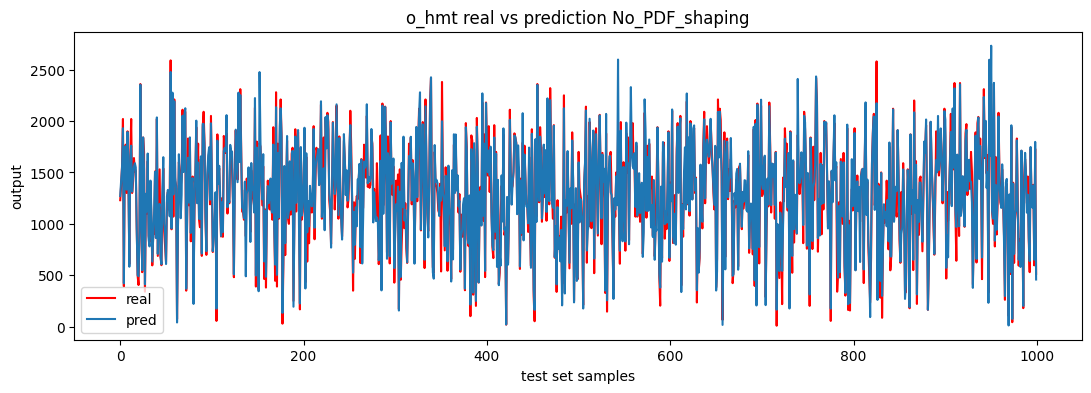

/Users/user/Desktop/CIVS_last_Phase/Forward/2025september/New5000SamplesDataset/PDFshapingUtils.py:353: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(error, bins=n_bins, color="blue")


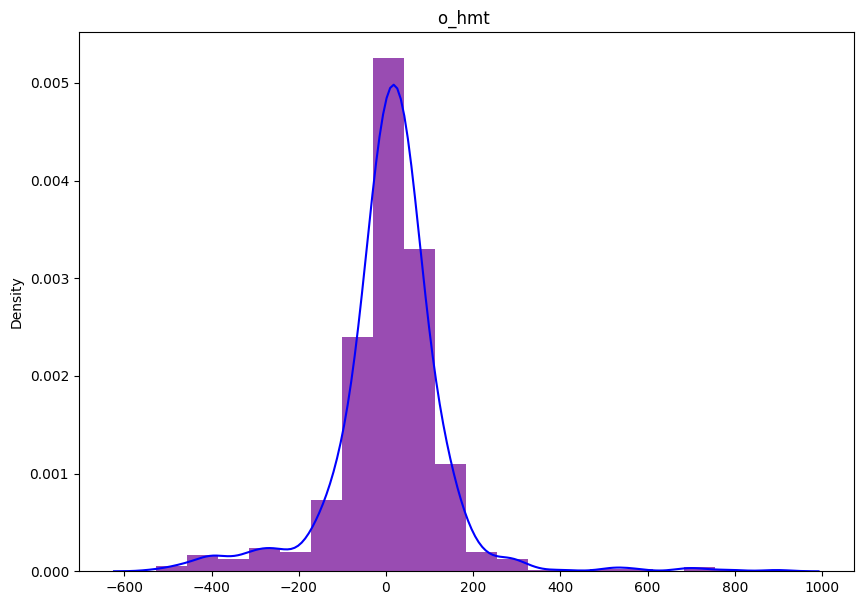

In [32]:

PDFshapingOBJ.plot_preds_vs_reals( list_preds, list_reals )


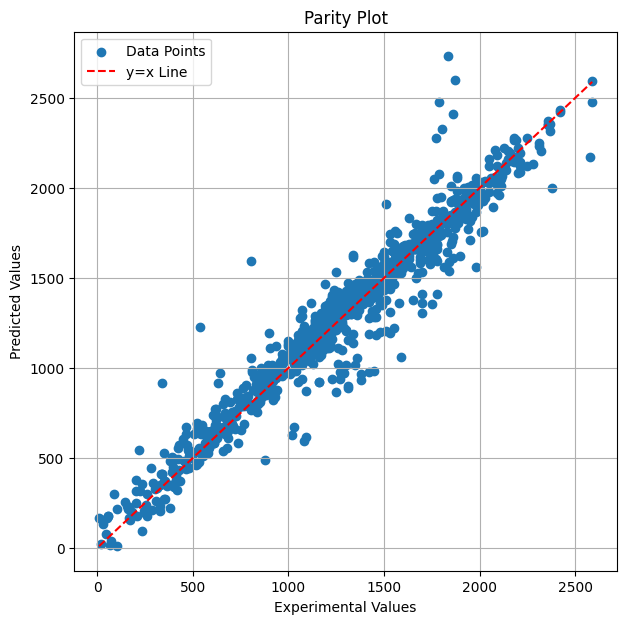

In [33]:

import matplotlib.pyplot as plt
import numpy as np

# Example data: Replace with your actual experimental and predicted values
## experimental_values = np.array([10, 20, 30, 40, 50])
## predicted_values    = np.array([11, 19, 32, 38, 51])

experimental_values = list_reals
predicted_values    = list_preds



plt.figure(figsize=(7, 7)) # Adjust figure size as needed
plt.scatter(experimental_values, predicted_values, label='Data Points')
plt.plot([min(experimental_values), max(experimental_values)],
        [min(experimental_values), max(experimental_values)],
        '--r', label='y=x Line') # Red dashed line for y=x

plt.xlabel('Experimental Values')
plt.ylabel('Predicted Values')
plt.title('Parity Plot')
plt.legend()
plt.grid(True)
plt.show()




## Export ONNX model


In [34]:


name_to_use_onnx = "ONNXmodels/F1plusF2NNs_" + ONNX_name + ".onnx"

model.eval()

dummy_input = torch.randn(1, 14)


input_names = ["input1"]
output_names = ["output1", "output2"]

torch.onnx.export(
  model, 
  dummy_input, 
  name_to_use_onnx, 
  verbose=False, 
  input_names  = input_names,
  output_names = output_names
)




## To compare NNs to XGBoost


In [35]:

##      y_pred = regressor.predict(PDFshapingOBJ.X_test )

pred_descaled, pred_scaled = model(PDFshapingOBJ.X_test_tr)


In [36]:

pred_descaled


tensor([[1257.1548],
        [1418.9308],
        [1533.7609],
        [1933.7932],
        [ 460.1130],
        [1746.0686],
        [1743.1355],
        [1321.5160],
        [1905.7977],
        [1468.6354],
        [ 600.6600],
        [1668.3262],
        [1927.4052],
        [1321.7788],
        [1444.7559],
        [1632.9064],
        [1590.2601],
        [1540.4885],
        [1063.4258],
        [ 491.0560],
        [ 491.2214],
        [ 929.2709],
        [2356.7212],
        [1162.8419],
        [ 572.9697],
        [1895.8550],
        [1643.1366],
        [ 331.7434],
        [1260.3699],
        [1121.2928],
        [1683.9059],
        [ 881.8458],
        [ 901.9996],
        [1383.6578],
        [1101.4983],
        [ 632.7374],
        [ 891.5311],
        [ 958.7878],
        [1506.0336],
        [ 875.7523],
        [2033.4098],
        [ 707.6022],
        [1149.1284],
        [1193.6879],
        [ 689.8718],
        [ 607.5934],
        [1163.2421],
        [1637

In [37]:

## r2_score( PDFshapingOBJ.y_test, y_pred )

print('Testing R**2 - scaled:', r2_score( pred_scaled.detach().numpy(), PDFshapingOBJ.y_test_tr_scaled.numpy() ))
print('Testing R**2 - descaled:', r2_score( pred_descaled.detach().numpy(), PDFshapingOBJ.y_test_tr.numpy()    ))


Testing R**2 - scaled: 0.9540166612948981
Testing R**2 - descaled: 0.9540166609018212



## Results for g(x) = F1(x) + F2(x) with PDF shaping

F1 = Linear

F2 = Nonlinear


In [38]:

def fit_y_scaled_PDF(num_epochs, num_epochs_pdf, model, loss_fn, opt, kl_loss, scheduler):
    
    PDFshapingOBJ.list_metric = []
      
    for epoch in range(num_epochs):
        for xb, yb in PDFshapingOBJ.train_dl:
            
            pred_descaled, pred_scaled = model(xb)
            loss = loss_fn(pred_scaled, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
            
            
        if epoch % 200 == 0:
            print(epoch, " loss= ", loss)
        
        pred_descaled, pred_scaled = model(PDFshapingOBJ.X_train_tr)
        r2_avg = torch.mean(torch.tensor(
                r2_score( pred_scaled.detach().numpy(),  PDFshapingOBJ.y_train_tr_scaled.numpy()  )
        ))
        PDFshapingOBJ.list_metric.append(r2_avg.detach().numpy())
        
        
    opt = torch.optim.Adam(   model.parameters(), lr=PDFshapingOBJ.learning_rate_pdfcontrol  )    
        
    for epoch in range(num_epochs_pdf):
        
        pred_descaled, pred_scaled = model(PDFshapingOBJ.X_train_tr)
       
        error =   pred_scaled.float() - PDFshapingOBJ.y_train_tr_scaled.float()          ## 715  x 1
        
        basisFunc = PDFshapingOBJ.train_multiple_kernels_per_output( error )             ## 1000 x 1
        
        p_pred = basisFunc.float() 
        q_real = PDFshapingOBJ.impulse_func_vector_vals.unsqueeze(1).float() 
        
        
        diff = ( p_pred - q_real )**2              ## 1000 x 1
        diff = diff * PDFshapingOBJ.quadratic_weights.unsqueeze(1)      
          
        
        loss = torch.mean( diff  ) 
        

        ## loss_diff = loss_fn(p_pred, q_real)
        ## input_kl  = F.log_softmax(p_pred, dim=0) # F.log_softmax(p_kl)
        ## target_kl = F.softmax(    q_real, dim=0) # F.softmax(q_kl)
        ## loss =  loss_diff   ## kl_loss(input_kl, target_kl)  ##   +  torch.std(p_pred)
        
        
        opt.zero_grad()
        loss.backward()
        opt.step()
        
      
        
        ## PDFshapingOBJ.updateImpulseGaussian_with_new_standard_deviation(decay_impulse_std )
        

        ## print(epoch, " loss= ", loss)
        if epoch % 5000 == 0:
            print(epoch, " loss= ", loss)
            print(PDFshapingOBJ.impulse_func_vector_vals.shape )
            print(PDFshapingOBJ.quadratic_weights.shape)
            print(error.shape)
            print(basisFunc.shape)
            ##### PDFshapingOBJ.print_errors_kdes(  error, basisFunc )
            print(PDFshapingOBJ.impulse_func_vector_vals.shape)
            print('Epoch-{0} lr: {1}'.format(epoch, opt.param_groups[0]['lr']))
      

        r2_avg = torch.mean(torch.tensor(
                 r2_score( pred_scaled.detach().numpy(),  PDFshapingOBJ.y_train_tr_scaled.numpy()  )
        ))
        PDFshapingOBJ.list_metric.append(  r2_avg.detach().numpy()  )
        
        
            
    PDFshapingOBJ.func_plot_performance()
            
    pred_descaled, pred_scaled = model(PDFshapingOBJ.X_train_tr)
    print('Training loss:', loss_fn(  pred_scaled,       PDFshapingOBJ.y_train_tr_scaled          ))
    print('Training R**2:', r2_score( pred_scaled.detach().numpy(), PDFshapingOBJ.y_train_tr_scaled.numpy() ))
    


In [39]:

PDFshapingOBJ.the_string           = "With_PDF_shaping"
PDFshapingOBJ.furnace_model_name   = ONNX_name

PDFshapingOBJ.learning_rate_pdfcontrol  = 0.001       ## 0.001
PDFshapingOBJ.N_EPOCHS_PDF              = 2000
PDFshapingOBJ.N_EPOCHS                  = 0

decay_impulse_std                       = PDFshapingOBJ.std_impulse / PDFshapingOBJ.N_EPOCHS_PDF 


666
0  loss=  tensor(0.0199, grad_fn=<MeanBackward0>)
torch.Size([1000])
torch.Size([1000])
torch.Size([3999, 1])
torch.Size([1000, 1])
torch.Size([1000])
Epoch-0 lr: 0.001


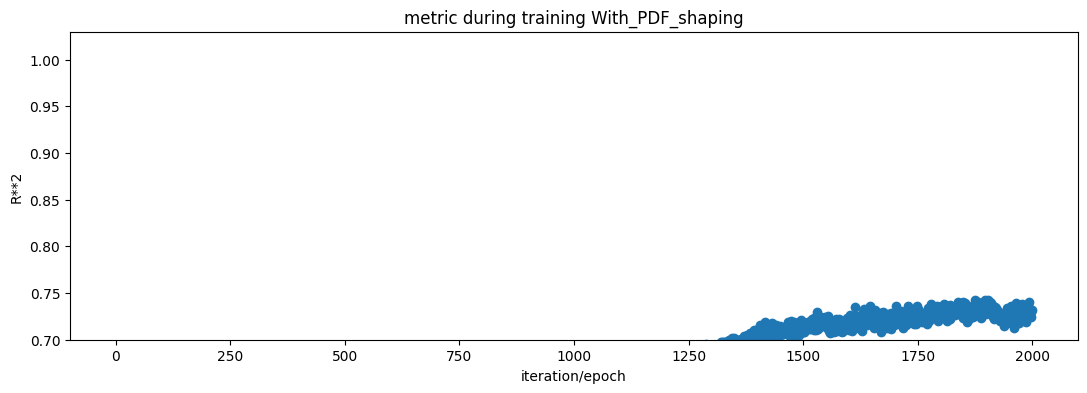

Training loss: tensor(0.2728, grad_fn=<MseLossBackward0>)
Training R**2: 0.735376794163327
Test loss - scaled: tensor(0.5178, grad_fn=<MseLossBackward0>)
Test loss - descaled: tensor(143493.0625, grad_fn=<MseLossBackward0>)
Testing R**2 - scaled: 0.5478132636861132
Testing R**2 - descaled: 0.5478132655027426
*****
*****
Testing R**2 - Output: 0 o_hmt 0.5478132655027426


In [40]:

model = F1plusF2_SIO(
             PDFshapingOBJ.x_means, 
             PDFshapingOBJ.x_deviations, 
             PDFshapingOBJ.y_means, 
             PDFshapingOBJ.y_deviations
)



opt         = torch.optim.Adam(   model.parameters(), lr=PDFshapingOBJ.learning_rate_pdfcontrol    )


step_size_scheduler = int(PDFshapingOBJ.N_EPOCHS_PDF / 3)
print(step_size_scheduler)
                          
scheduler   = torch.optim.lr_scheduler.StepLR(opt, step_size=1000, gamma=0.1)



loss_fn      = F.mse_loss
kl_loss      = nn.KLDivLoss(reduction="batchmean")
loss_softmax = F.binary_cross_entropy


fit_y_scaled_PDF(PDFshapingOBJ.N_EPOCHS, PDFshapingOBJ.N_EPOCHS_PDF, model, loss_fn, opt, kl_loss, scheduler)

pred_descaled, pred_scaled = model(PDFshapingOBJ.X_test_tr)
print('Test loss - scaled:',   loss_fn(     pred_scaled,       PDFshapingOBJ.y_test_tr_scaled          ))
print('Test loss - descaled:', loss_fn(     pred_descaled,     PDFshapingOBJ.y_test_tr                 ))
print('Testing R**2 - scaled:',   r2_score( pred_scaled.detach().numpy(),PDFshapingOBJ.y_test_tr_scaled.numpy() ))
print('Testing R**2 - descaled:', r2_score( pred_descaled.detach().numpy(), PDFshapingOBJ.y_test_tr.numpy()   ))


PDFshapingOBJ.print_individual_Rsquare(pred_descaled, PDFshapingOBJ.y_test_tr)


In [41]:

list_preds = []
list_reals = []

for i in range(len(PDFshapingOBJ.X_test_tr)):
    print("**************************************************")
    print("preds, real")
    preds_descaled, preds_scaled = model(PDFshapingOBJ.X_test_tr[i])

    np_pred = preds_descaled[0].detach().numpy()              ## [0]
    np_real = PDFshapingOBJ.y_test_tr[i].detach().numpy()

    for j in range(len(np_pred)):
        print((np_pred[j], np_real[j]))
        list_preds.append(np_pred[j])
        list_reals.append(np_real[j])


**************************************************
preds, real
(1259.8613, 1230.0)
**************************************************
preds, real
(1395.9003, 1370.0)
**************************************************
preds, real
(1343.1152, 1560.0)
**************************************************
preds, real
(1933.287, 2020.0)
**************************************************
preds, real
(529.57184, 391.0)
**************************************************
preds, real
(1627.258, 1670.0)
**************************************************
preds, real
(1842.8054, 1770.0)
**************************************************
preds, real
(1345.109, 1300.0)
**************************************************
preds, real
(1898.1038, 1900.0)
**************************************************
preds, real
(1647.3186, 1420.0)
**************************************************
preds, real
(639.6953, 608.0)
**************************************************
preds, real
(1660.0792, 1660.0)
**********

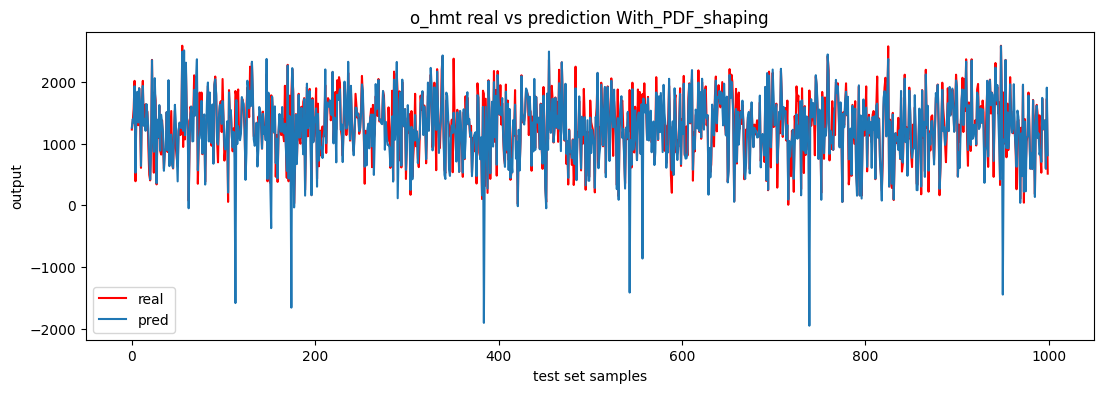

/Users/user/Desktop/CIVS_last_Phase/Forward/2025september/New5000SamplesDataset/PDFshapingUtils.py:353: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(error, bins=n_bins, color="blue")


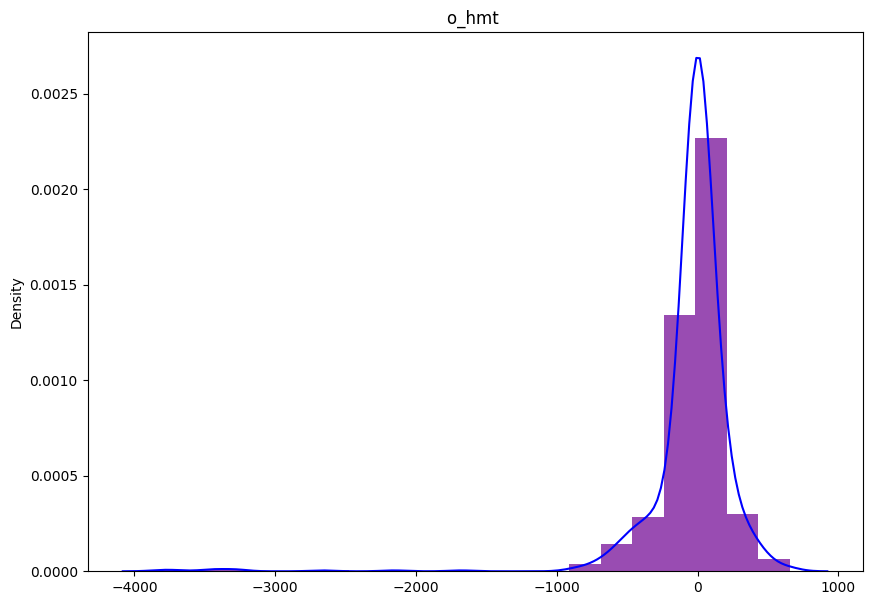

In [42]:

PDFshapingOBJ.plot_preds_vs_reals( list_preds, list_reals )


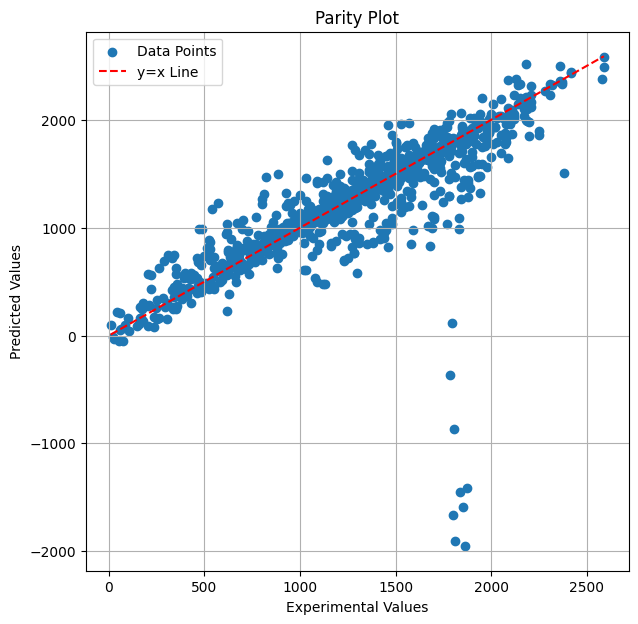

In [43]:

import matplotlib.pyplot as plt
import numpy as np

# Example data: Replace with your actual experimental and predicted values
## experimental_values = np.array([10, 20, 30, 40, 50])
## predicted_values    = np.array([11, 19, 32, 38, 51])

experimental_values = list_reals
predicted_values    = list_preds



plt.figure(figsize=(7, 7)) # Adjust figure size as needed
plt.scatter(experimental_values, predicted_values, label='Data Points')
plt.plot([min(experimental_values), max(experimental_values)],
        [min(experimental_values), max(experimental_values)],
        '--r', label='y=x Line') # Red dashed line for y=x

plt.xlabel('Experimental Values')
plt.ylabel('Predicted Values')
plt.title('Parity Plot')
plt.legend()
plt.grid(True)
plt.show()




## To compare to NNs to XGBoost


In [44]:

##      y_pred = regressor.predict(PDFshapingOBJ.X_test )

pred_descaled, pred_scaled = model(PDFshapingOBJ.X_test_tr)


In [45]:

## y_pred

pred_descaled


tensor([[ 1390.2152],
        [ 1398.2186],
        [ 1477.3358],
        [ 1879.4839],
        [  620.7201],
        [ 1653.9263],
        [ 1983.3206],
        [ 1317.6161],
        [ 1882.5522],
        [ 1675.0332],
        [  650.8549],
        [ 1621.8008],
        [ 1764.8521],
        [ 1272.2972],
        [ 1439.2974],
        [ 1499.8097],
        [ 1596.3031],
        [ 1547.9403],
        [ 1382.8175],
        [  592.7367],
        [  546.0014],
        [  860.6392],
        [ 2348.2661],
        [ 1216.3870],
        [  993.1317],
        [ 2241.5229],
        [ 1559.0447],
        [  358.3517],
        [ 1194.6006],
        [ 1093.7693],
        [ 1637.9037],
        [  972.5502],
        [ 1325.1868],
        [ 1335.9116],
        [ 1131.8976],
        [  556.8845],
        [  901.6722],
        [  942.6412],
        [ 1535.4421],
        [  865.9868],
        [ 2027.0328],
        [  654.9134],
        [ 1100.7997],
        [ 1201.4142],
        [  633.3504],
        [ 

In [46]:

## r2_score( PDFshapingOBJ.y_test, y_pred )

print('Testing R**2 - scaled:', r2_score( pred_scaled.detach().numpy(), PDFshapingOBJ.y_test_tr_scaled.numpy() ))
print('Testing R**2 - descaled:', r2_score( pred_descaled.detach().numpy(), PDFshapingOBJ.y_test_tr.numpy()    ))


Testing R**2 - scaled: 0.5454845280720437
Testing R**2 - descaled: 0.5454845371058842



## Export ONNX model


In [47]:

'''

model.eval()

dummy_input = torch.randn(1, 6)


input_names = ["input1"]
output_names = ["output1", "output2"]

torch.onnx.export(
  model, 
  dummy_input, 
  "ONNXmodels/s894TuyereExitVeloMsPDFshapingRC.onnx", 
  verbose=False, 
  input_names  = input_names,
  output_names = output_names
)

'''


'\n\nmodel.eval()\n\ndummy_input = torch.randn(1, 6)\n\n\ninput_names = ["input1"]\noutput_names = ["output1", "output2"]\n\ntorch.onnx.export(\n  model, \n  dummy_input, \n  "ONNXmodels/s894TuyereExitVeloMsPDFshapingRC.onnx", \n  verbose=False, \n  input_names  = input_names,\n  output_names = output_names\n)\n\n'


## XGBoost


In [48]:

regressor = xgb.XGBRegressor(
    n_estimators=100,
    reg_lambda=1,
    gamma=0,
    max_depth=3
)


In [49]:

regressor.fit(PDFshapingOBJ.X_train, PDFshapingOBJ.y_train)


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.300000012, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=3, max_leaves=0, min_child_weight=1,
             missing=nan, monotone_constraints='()', n_estimators=100, n_jobs=0,
             num_parallel_tree=1, predictor='auto', random_state=0, reg_alpha=0,
             reg_lambda=1, ...)

In [50]:

print( len(PDFshapingOBJ.X_train  ))
print( len(PDFshapingOBJ.y_train  ))
  


3999
3999


In [51]:

## columns_thing = ['i_h2_inj_kg_thm', 'i_pul_coal_inj_kg_thm', 'i_nat_gas_inj_kg_thm', 'i_nat_gas_t_k', 
##                  'i_o2_vol_perce', 'i_hot_blast_temp_k', ]



## pd.DataFrame(regressor.feature_importances_.reshape(1, -1), columns=columns_thing)


In [52]:

y_pred = regressor.predict(PDFshapingOBJ.X_test )


In [53]:

y_pred


array([1202.6912    , 1389.113     , 1582.1266    , 1950.875     ,
        363.79245   , 1677.478     , 1768.1631    , 1331.1449    ,
       1916.3787    , 1405.969     ,  645.7565    , 1646.5714    ,
       1994.804     , 1383.2755    , 1383.5663    , 1574.6667    ,
       1506.6923    , 1561.0872    , 1056.8787    ,  455.1339    ,
        403.27856   ,  905.87415   , 2349.5247    , 1211.8367    ,
        540.56006   , 1880.1674    , 1625.7917    ,  236.52698   ,
       1200.9052    , 1018.79724   , 1556.3381    ,  836.40796   ,
        728.07886   , 1376.8033    , 1006.4429    ,  578.63416   ,
        848.5005    ,  851.8844    , 1514.1963    ,  829.1658    ,
       1982.9572    ,  692.1489    , 1095.5348    , 1277.6775    ,
        635.1016    ,  506.2518    , 1118.2599    , 1586.9926    ,
       1009.57666   ,  822.5641    ,  577.92926   , 1138.9685    ,
       1331.2418    , 1156.2805    , 1078.3961    , 2495.9807    ,
        938.2673    , 2304.0193    , 1096.0137    , 2303.2961 

In [54]:

mean_squared_error(PDFshapingOBJ.y_test , y_pred)


7578.975

In [55]:

r2_score( PDFshapingOBJ.y_test, y_pred )


0.970910134110307

In [56]:

len(y_pred) 


1000

In [57]:

list_preds = []
list_reals = []

print( "preds, real"   )
  
for j in range(   len(y_pred)    ):
    print(   y_pred[j], PDFshapingOBJ.y_test[j][0]   )
    
    list_preds.append(   y_pred[j]   )
    list_reals.append(  PDFshapingOBJ.y_test[j][0]   )


preds, real
1202.6912 1230.0
1389.113 1370.0
1582.1266 1560.0
1950.875 2020.0
363.79245 391.0
1677.478 1670.0
1768.1631 1770.0
1331.1449 1300.0
1916.3787 1900.0
1405.969 1420.0
645.7565 608.0
1646.5714 1660.0
1994.804 2020.0
1383.2755 1300.0
1383.5663 1410.0
1574.6667 1640.0
1506.6923 1510.0
1561.0872 1520.0
1056.8787 969.0
455.1339 495.0
403.27856 405.0
905.87415 920.0
2349.5247 2360.0
1211.8367 1200.0
540.56006 530.0
1880.1674 1840.0
1625.7917 1700.0
236.52698 340.0
1200.9052 1210.0
1018.79724 1100.0
1556.3381 1610.0
836.40796 883.0
728.07886 824.0
1376.8033 1380.0
1006.4429 1050.0
578.63416 596.0
848.5005 894.0
851.8844 904.0
1514.1963 1510.0
829.1658 865.0
1982.9572 2020.0
692.1489 688.0
1095.5348 1110.0
1277.6775 1530.0
635.1016 676.0
506.2518 598.0
1118.2599 1170.0
1586.9926 1540.0
1009.57666 925.0
822.5641 780.0
577.92926 626.0
1138.9685 1210.0
1331.2418 1310.0
1156.2805 1140.0
1078.3961 1170.0
2495.9807 2590.0
938.2673 947.0
2304.0193 2180.0
1096.0137 1070.0
2303.2961 2210.0
14

In [58]:

len( list_preds )


1000

In [59]:

len( list_reals )


1000

In [60]:

PDFshapingOBJ.the_string           = "XGBoost"
PDFshapingOBJ.furnace_model_name   = ONNX_name


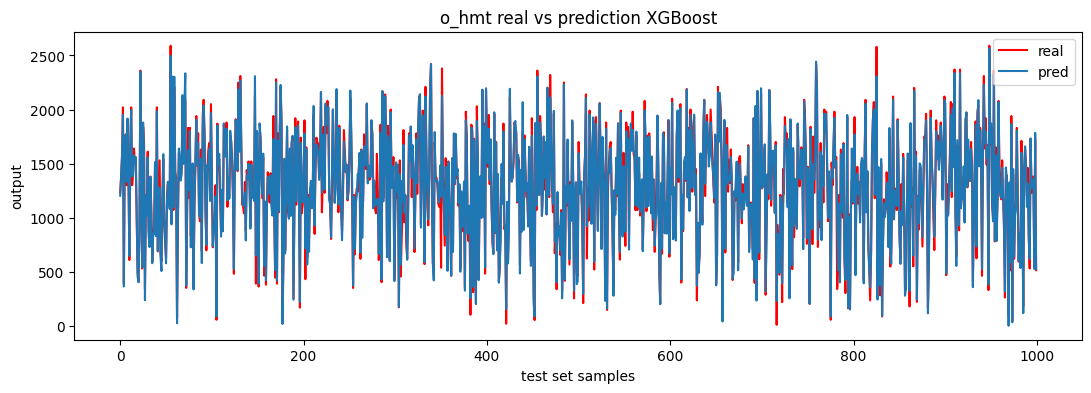

/Users/user/Desktop/CIVS_last_Phase/Forward/2025september/New5000SamplesDataset/PDFshapingUtils.py:353: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(error, bins=n_bins, color="blue")


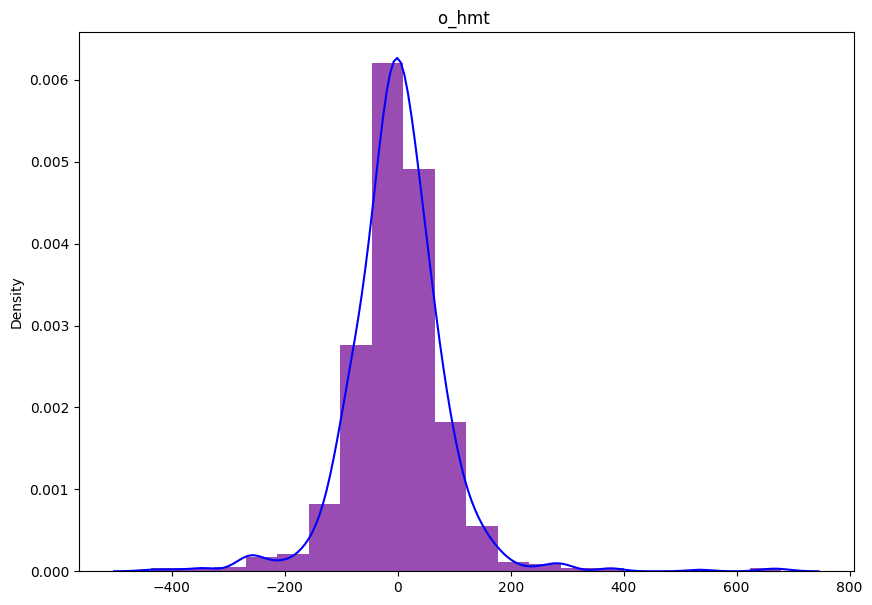

In [61]:

PDFshapingOBJ.plot_preds_vs_reals( list_preds, list_reals )


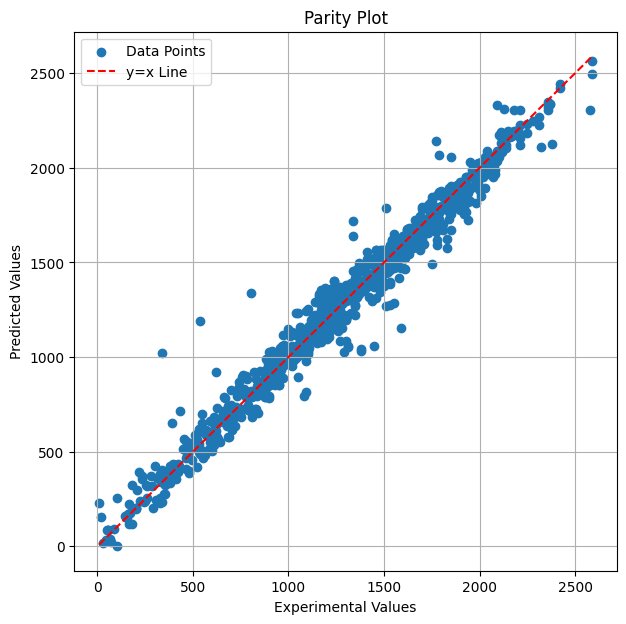

In [62]:

import matplotlib.pyplot as plt
import numpy as np

# Example data: Replace with your actual experimental and predicted values
## experimental_values = np.array([10, 20, 30, 40, 50])
## predicted_values    = np.array([11, 19, 32, 38, 51])

experimental_values = list_reals
predicted_values    = list_preds



plt.figure(figsize=(7, 7)) # Adjust figure size as needed
plt.scatter(experimental_values, predicted_values, label='Data Points')
plt.plot([min(experimental_values), max(experimental_values)],
        [min(experimental_values), max(experimental_values)],
        '--r', label='y=x Line') # Red dashed line for y=x

plt.xlabel('Experimental Values')
plt.ylabel('Predicted Values')
plt.title('Parity Plot')
plt.legend()
plt.grid(True)
plt.show()




## ONNX and XGboost


In [63]:

model = xgb.XGBRegressor(
    n_estimators=100,
    reg_lambda=1,
    gamma=0,
    max_depth=3
)


In [64]:


print(model)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, gamma=0, gpu_id=None,
             grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, predictor=None, random_state=None,
             reg_alpha=None, reg_lambda=1, ...)


In [65]:

model.fit( PDFshapingOBJ.X_train, PDFshapingOBJ.y_train)


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.300000012, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=3, max_leaves=0, min_child_weight=1,
             missing=nan, monotone_constraints='()', n_estimators=100, n_jobs=0,
             num_parallel_tree=1, predictor='auto', random_state=0, reg_alpha=0,
             reg_lambda=1, ...)

In [66]:

y_pred = model.predict(PDFshapingOBJ.X_test )


In [67]:

y_pred


array([1202.6912    , 1389.113     , 1582.1266    , 1950.875     ,
        363.79245   , 1677.478     , 1768.1631    , 1331.1449    ,
       1916.3787    , 1405.969     ,  645.7565    , 1646.5714    ,
       1994.804     , 1383.2755    , 1383.5663    , 1574.6667    ,
       1506.6923    , 1561.0872    , 1056.8787    ,  455.1339    ,
        403.27856   ,  905.87415   , 2349.5247    , 1211.8367    ,
        540.56006   , 1880.1674    , 1625.7917    ,  236.52698   ,
       1200.9052    , 1018.79724   , 1556.3381    ,  836.40796   ,
        728.07886   , 1376.8033    , 1006.4429    ,  578.63416   ,
        848.5005    ,  851.8844    , 1514.1963    ,  829.1658    ,
       1982.9572    ,  692.1489    , 1095.5348    , 1277.6775    ,
        635.1016    ,  506.2518    , 1118.2599    , 1586.9926    ,
       1009.57666   ,  822.5641    ,  577.92926   , 1138.9685    ,
       1331.2418    , 1156.2805    , 1078.3961    , 2495.9807    ,
        938.2673    , 2304.0193    , 1096.0137    , 2303.2961 

In [68]:

r2_score( PDFshapingOBJ.y_test, y_pred )


0.970910134110307

In [69]:

initial_types = [(
         'float_input', 
         FloatTensorType(     [ None, PDFshapingOBJ.X.shape[1] ]       )
)]


In [70]:

onnx_name_to_use = 'ONNXmodels/xgboost_' + ONNX_name + '_ort.onnx'

## target_opset=7

onnx_model = onnxmltools.convert_xgboost(model, initial_types=initial_types)

onnxmltools.utils.save_model(onnx_model, onnx_name_to_use)


In [71]:

onnx_name_to_use = 'ONNXmodels/xgboost_' + ONNX_name + '_ort.onnx'

# Setup runtime. This instantiates an ONNX inference session and loads the persisted model.
sess = rt.InferenceSession( onnx_name_to_use )


In [72]:

# Get model metadata to enable mapping of new input to the runtime model
input_name = sess.get_inputs()[0].name
label_name = sess.get_outputs()[0].name


In [73]:

input_name 


'float_input'

In [74]:

label_name


'variable'

In [75]:

# Create predictions. The inputs are the xtest values, and they are being casted as type float32.
pred_onnx = sess.run([label_name], {input_name: PDFshapingOBJ.X_test.astype(np.float32)})[0]


In [76]:

# Print first 10 predictions
print("Prediction:\n", pred_onnx[0:10])


Prediction:
 [[1202.691 ]
 [1389.1128]
 [1582.1266]
 [1950.8749]
 [ 363.7924]
 [1677.4781]
 [1768.1631]
 [1331.1448]
 [1916.3782]
 [1405.9692]]


In [77]:

test_count = 10
test_cases = PDFshapingOBJ.X_test[0:test_count]
local_pred = model.predict(test_cases)
print(f"Local predictions are: {local_pred}")


Local predictions are: [1202.6912  1389.113   1582.1266  1950.875    363.79245 1677.478
 1768.1631  1331.1449  1916.3787  1405.969  ]


In [78]:

test_cases


array([[   0. ,    0. ,    0. ,   70. ,   24. ,  500. ,    0. , 1448. ,
         195. ,    5.7,    7. ,    0. ,    0. ,    0. ],
       [   0. ,  150. ,    0. ,    0. ,   21. ,    0. ,    0. , 1600. ,
         230. ,    5.7,    5. ,    0. ,    0. ,    0. ],
       [  10. ,    0. ,    0. ,    0. ,   24. ,    0. ,  300. , 1600. ,
         160. ,    5.7,    5. ,    0. ,    0. ,    0. ],
       [  10. ,    0. ,    0. ,    0. ,   30. ,    0. ,  600. , 1480. ,
         160. ,    5.7,    5. ,    0. ,    0. ,    0. ],
       [   0. ,    0. ,    0. ,  150. ,   24. ,  500. ,    0. , 1600. ,
         160. ,    5.7,    7. ,    0. ,    0. ,    0. ],
       [  10. ,    0. ,    0. ,    0. ,   21. ,    0. ,  600. , 1600. ,
         230. ,    5.7,    1. ,    0. ,    0. ,    0. ],
       [   0. ,    0. ,    0. ,   41. ,   27. ,  500. ,    0. , 1600. ,
         160. ,    5.7,    3. ,    0. ,    0. ,    0. ],
       [   0. ,  200. ,    0. ,    0. ,   24. ,    0. ,    0. , 1600. ,
         195. ,    5.7,  


## ONNX, XGBoost, and SKlearn pipeline


In [79]:

update_registered_converter(
    XGBRegressor, 'XGBoostXGBRegressor',
    calculate_linear_regressor_output_shapes, 
    convert_xgboost
)


In [80]:

model = xgb.XGBRegressor(
    n_estimators=100,
    reg_lambda=1,
    gamma=0,
    max_depth=3
)

pipe = Pipeline([
            ('xgb', model) 
])



pipe.fit( PDFshapingOBJ.X_train, PDFshapingOBJ.y_train)


Pipeline(steps=[('xgb',
                 XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
                              colsample_bylevel=1, colsample_bynode=1,
                              colsample_bytree=1, early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              gamma=0, gpu_id=-1, grow_policy='depthwise',
                              importance_type=None, interaction_constraints='',
                              learning_rate=0.300000012, max_bin=256,
                              max_cat_to_onehot=4, max_delta_step=0,
                              max_depth=3, max_leaves=0, min_child_weight=1,
                              missing=nan, monotone_constraints='()',
                              n_estimators=100, n_jobs=0, num_parallel_tree=1,
                              predictor='auto', random_state=0, reg_alpha=0,
                              reg_lambda=1, ...))])

In [81]:

y_pred = pipe.predict(PDFshapingOBJ.X_test )


In [82]:

y_pred


array([1202.6912    , 1389.113     , 1582.1266    , 1950.875     ,
        363.79245   , 1677.478     , 1768.1631    , 1331.1449    ,
       1916.3787    , 1405.969     ,  645.7565    , 1646.5714    ,
       1994.804     , 1383.2755    , 1383.5663    , 1574.6667    ,
       1506.6923    , 1561.0872    , 1056.8787    ,  455.1339    ,
        403.27856   ,  905.87415   , 2349.5247    , 1211.8367    ,
        540.56006   , 1880.1674    , 1625.7917    ,  236.52698   ,
       1200.9052    , 1018.79724   , 1556.3381    ,  836.40796   ,
        728.07886   , 1376.8033    , 1006.4429    ,  578.63416   ,
        848.5005    ,  851.8844    , 1514.1963    ,  829.1658    ,
       1982.9572    ,  692.1489    , 1095.5348    , 1277.6775    ,
        635.1016    ,  506.2518    , 1118.2599    , 1586.9926    ,
       1009.57666   ,  822.5641    ,  577.92926   , 1138.9685    ,
       1331.2418    , 1156.2805    , 1078.3961    , 2495.9807    ,
        938.2673    , 2304.0193    , 1096.0137    , 2303.2961 

In [83]:

r2_score( PDFshapingOBJ.y_test, y_pred )


0.970910134110307

In [84]:

onnx_name_to_use = 'pipeline_xgboost_' + ONNX_name

model_onnx = convert_sklearn(
    pipe, 
    onnx_name_to_use,
    [ ('input', FloatTensorType([None, PDFshapingOBJ.X.shape[1]])) ],
    target_opset={'': 7, 'ai.onnx.ml': 1})


In [85]:

onnx_name_to_use = "ONNXmodels/pipeline_xgboost_" + ONNX_name + ".onnx"

with open(onnx_name_to_use, "wb") as f:
    f.write(model_onnx.SerializeToString())
    

In [86]:
onx = to_onnx(pipe, PDFshapingOBJ.X_test.astype(np.float32),
              target_opset={'': 7, 'ai.onnx.ml': 1})

sess = rt.InferenceSession(onx.SerializeToString())
pred_onx = sess.run(None, {"X": PDFshapingOBJ.X_test[:5].astype(np.float32)})
print("predict", pred_onx[0].ravel())



predict [1202.6912  1389.113   1582.1266  1950.875    363.79245]


In [87]:

input_name = sess.get_inputs()[0].name
label_name = sess.get_outputs()[0].name


In [88]:
label_name 

'variable'

In [89]:
input_name 

'X'